# Chapter 6. Which checks must pass before the collected number leaves the team, and what does Anand get when one fails at the end of reporting day?

**Week 2, Tuesday · Chapter 6 of 6 · Booked against collected.**

> **The client asks.** "Booked revenue is not collected revenue. Some orders are paid in two
> instalments, some are refunded, some were never paid at all. Show me, order by order, what we
> actually collected against what we booked in Q2. If there is a gap, I want to know which orders
> and which channel."
>
> Anand Iyer, finance controller, Kalpa Retail

The data platform lead added the payments table to the team's access and said, in passing, that
the payments feed "sometimes double-posts when the gateway retries".

**Who needs the answer.** Kavya, who reviews every number before it leaves the team; Anand, who forwards it to the CEO's Monday page; and you, who sign it. A validation that cannot fail puts a PASS stamp on a wrong number, and a stamped wrong number is harder to withdraw than an unstamped one.

**The questions on the way.**
1. Do the checks a hurried analyst writes pass a report that hides an unpaid order?
2. Which checks tie the report back to the two tables?
3. Does the suite fail every wrong report the day has met?
4. Does it pass Kalpa's Q2 report?
5. Does a second tool, working from the raw rows, reach the same numbers?
6. What does Anand get when a check fails at the end of reporting day?

**The metric at stake.** The collected figure and its gap, every Monday, and the checks that stand between them and Anand: which of the day's wrong reports each check would stop.

**What came before, and what this adds.** Chapter 5 built the page Anand signs: one line per channel, with orders, booked, collected and a gap that uses `coalesce(collected, 0)`, so an unpaid order counts as nothing paid. On the invented tables app's gap is 800, T-4; on Kalpa's Q2 you built the page and it added back to the bridge. Over the day five wrong reports appeared, each plausible: the fan-out draft, the plain JOIN, the quarter in WHERE, each order's gap added up, and posted read as collected. This chapter builds the checks that stop all five, every Monday, before the number leaves.

**Setup.** The next cell finds the helper, connects to the warehouse, creates the invented tables of
chapter 1, and rebuilds the day's five wrong reports on them exactly as each chapter's trap wrote
them. Every query below is also in `sql/C2_W02_D02_06_can_it_leave_STUDENT.sql`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
from decimal import Decimal

TINY = """DROP TABLE IF EXISTS tiny_orders, tiny_payments;
CREATE TEMP TABLE tiny_orders (
    order_id  text PRIMARY KEY,
    channel   text NOT NULL,
    amount    numeric(12, 2) NOT NULL
);
CREATE TEMP TABLE tiny_payments (
    payment_id    text PRIMARY KEY,
    order_id      text NOT NULL,
    paid_date     date NOT NULL,
    amount        numeric(12, 2) NOT NULL,
    instalment_no integer NOT NULL
);
INSERT INTO tiny_orders VALUES
    ('T-1', 'app',   1000),
    ('T-2', 'web',   2000),
    ('T-3', 'store', 1500),
    ('T-4', 'app',    800),
    ('T-5', 'store',  500);
INSERT INTO tiny_payments VALUES
    ('P-1', 'T-1', '2026-07-03', 1000, 1),
    ('P-2', 'T-2', '2026-07-05', 1200, 1),
    ('P-3', 'T-2', '2026-08-05',  800, 2),
    ('P-4', 'T-3', '2026-07-09', 1500, 1),
    ('P-5', 'T-3', '2026-07-09', 1500, 1),
    ('P-6', 'T-5', '2026-07-12',  500, 1),
    ('P-7', 'T-9', '2026-07-14',  600, 1);"""

conn = kit.connect()
conn.autocommit = True
with conn.cursor() as cur:
    cur.execute(TINY)            # invented, TEMP, so they vanish when this notebook stops


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def one(query, params=None):
    """The first value of the first row, for a query that returns a single number."""
    row = run(query, params)[0]
    return next(iter(row.values()))


def show(rows, caption="", money=()):
    """Rows as the kit's table; columns named in money print as rupees."""
    if not rows:
        return kit.table(["result"], [["no rows"]], caption)
    heads = list(rows[0])
    body = []
    for r in rows:
        line = []
        for h in heads:
            v = r[h]
            if v is None:
                line.append("NULL")
            elif h in money:
                line.append(kit.rupees(v))
            elif isinstance(v, Decimal):
                line.append(f"{int(v):,}" if v == v.to_integral_value() else f"{float(v):,.2f}")
            else:
                line.append(str(v))
        body.append(line)
    kit.table(heads, body, caption)

PLAUSIBLE = [
    ("collected is at most booked", lambda r, s: r["collected"] <= r["booked"]),
    ("the gap is not negative", lambda r, s: r["gap"] is not None and r["gap"] >= 0),
    ("all three channels are on it", lambda r, s: set(r["channels"]) >= {"app", "store", "web"}),
]
TIE_BACK = [
    ("orders on the report equal orders in the table", lambda r, s: r["orders"] == s["orders"]),
    ("booked equals booked from orders alone", lambda r, s: r["booked"] == s["booked"]),
    ("the gap equals booked less collected", lambda r, s: r["gap"] == r["booked"] - r["collected"]),
    ("the gap equals the unpaid list's total", lambda r, s: r["gap"] == (s["never_paid"] or 0)),
    ("collected plus posted twice equals posted from payments alone",
     lambda r, s: r["collected"] + (s["posted_twice"] or 0) == s["posted"]),
]


def validate(report, source, suite):
    """Every check in the suite, run on one report against the single-table sources."""
    return [(name, bool(test(report, source))) for name, test in suite]

with conn.cursor() as cur:
    cur.execute("""
CREATE TEMP VIEW tiny_per_order AS
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM tiny_payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM tiny_orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id;
CREATE TEMP VIEW q2_per_order AS
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
WHERE o.quarter = 'Q2';""")   # chapter 3's per-order table, as TEMP views

WRONG = {}
WRONG['fan-out draft'] = """SELECT count(*) AS orders, sum(o.amount) AS booked,
       sum(o.amount) FILTER (WHERE p.payment_id IS NOT NULL) AS collected,
       sum(o.amount) - sum(o.amount) FILTER (WHERE p.payment_id IS NOT NULL) AS gap,
       array_agg(DISTINCT o.channel) AS channels
FROM tiny_orders o
LEFT JOIN tiny_payments p ON p.order_id = o.order_id"""
WRONG['plain JOIN'] = """SELECT count(*) AS orders, sum(booked) AS booked, sum(collected) AS collected,
       sum(booked) - sum(collected) AS gap, array_agg(DISTINCT channel) AS channels
FROM tiny_per_order
WHERE collected IS NOT NULL"""
WRONG['quarter in WHERE'] = """WITH per_order AS (
    SELECT o.order_id, o.channel, o.amount AS booked, sum(i.amount) AS collected
    FROM tiny_orders o
    LEFT JOIN (SELECT order_id, instalment_no, max(amount) AS amount, max(paid_date) AS paid_date
               FROM tiny_payments
               GROUP BY order_id, instalment_no) i ON i.order_id = o.order_id
    WHERE i.paid_date BETWEEN '2026-07-01' AND '2026-09-30'
    GROUP BY o.order_id, o.channel, o.amount
)
SELECT count(*) AS orders, sum(booked) AS booked, sum(collected) AS collected,
       sum(booked) - sum(collected) AS gap, array_agg(DISTINCT channel) AS channels
FROM per_order"""
WRONG['gap summed per order'] = """SELECT count(*) AS orders, sum(booked) AS booked, sum(collected) AS collected,
       sum(booked - collected) AS gap, array_agg(DISTINCT channel) AS channels
FROM tiny_per_order"""
WRONG['posted as collected'] = """SELECT count(*) AS orders, sum(booked) AS booked, sum(posted) AS collected,
       sum(booked) - sum(posted) AS gap, array_agg(DISTINCT channel) AS channels
FROM tiny_per_order"""
WRONG['true report'] = """SELECT count(*) AS orders, sum(booked) AS booked, sum(coalesce(collected, 0)) AS collected,
       sum(booked - coalesce(collected, 0)) AS gap, array_agg(DISTINCT channel) AS channels
FROM tiny_per_order"""

reports = {name: run(q)[0] for name, q in WRONG.items()}
src_tiny = run("""SELECT (SELECT count(*) FROM tiny_orders o)                           AS orders,
       (SELECT sum(amount) FROM tiny_orders o)                        AS booked,
       (SELECT sum(amount) FROM tiny_payments
         WHERE order_id IN (SELECT order_id FROM tiny_orders o))      AS posted,
       (SELECT sum(amount) FROM tiny_orders o WHERE
            NOT EXISTS (SELECT 1 FROM tiny_payments p
                        WHERE p.order_id = o.order_id))                   AS never_paid,
       (SELECT sum(extra)
          FROM (SELECT sum(p.amount) - max(p.amount) AS extra
                FROM tiny_payments p JOIN tiny_orders o ON o.order_id = p.order_id
                GROUP BY p.order_id, p.instalment_no) AS repeats)         AS posted_twice""")[0]
print("Rebuilt on the invented tables:", ", ".join(reports), sep="\n  ")

Rebuilt on the invented tables:
  fan-out draft, plain JOIN, quarter in WHERE, gap summed per order, posted as collected, true report


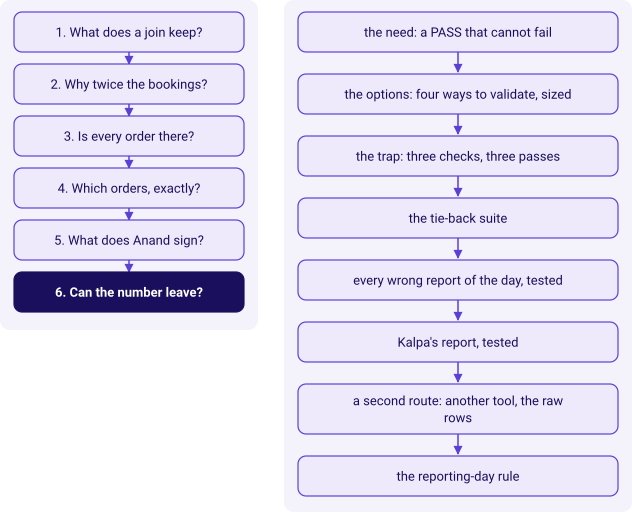

In [2]:
kit.side_by_side(
    kit.ladder(['What does a join keep?', 'Why twice the bookings?', 'Is every order there?', 'Which orders, exactly?', 'What does Anand sign?', 'Can the number leave?'], lit=5, show=False),
    kit.vflow(['the need: a PASS that cannot fail', 'the options: four ways to validate, sized', 'the trap: three checks, three passes', 'the tie-back suite', 'every wrong report of the day, tested', "Kalpa's report, tested", 'a second route: another tool, the raw rows', 'the reporting-day rule'], show=False),
)

## What does a PASS stamp cost when the check behind it could not fail?

The Monday number is refreshed every week, by whoever is on the rota, sometimes late on reporting
day. Checks are what let a number leave without Kavya reading every query. But a check is only worth
its power to fail: a suite that passes a wrong report does worse than no suite, because the PASS
line travels with the number and Anand forwards it with more confidence than he would forward an
unchecked one. The retail story behind Anand's role, how a sale becomes cash and who checks it, is in the domain dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, sections 3 and 4.

**Who else faces this.** Wirecard, a German payments company, collapsed in June 2020 over cash it
reported and did not have. On 18 June its auditor, EY, refused to sign the accounts because it could
not confirm that the money existed; on 22 June Wirecard said there was "a prevailing likelihood"
that 1.9 billion euros of trust account balances did not exist; on 25 June it filed for insolvency
(BBC News, 18, 22 and 25 June 2020, checked 30 Sep 2026). The Financial Times reported that from
2016 to 2018 the auditor had not checked directly with the bank said to hold the money, and relied
on documents and screenshots from a third-party trustee and from Wirecard itself (FT, republished
by the Irish Times, 26 June 2020, checked 30 Sep 2026). A check that reads a company's own records
back to it cannot fail.

**The two invented tables.** Five orders and seven payments, invented to carry every case Anand
named and the one the platform lead mentioned, so every row can be checked by hand:

| order_id | channel | amount | What happened to it |
|---|---|---|---|
| T-1 | app | 1,000 | Paid once, in full (P-1) |
| T-2 | web | 2,000 | Paid in two instalments, 1,200 and 800 (P-2, P-3) |
| T-3 | store | 1,500 | Paid once, and the gateway posted that payment twice (P-4, P-5) |
| T-4 | app | 800 | Never paid |
| T-5 | store | 500 | Paid once, in full (P-6) |

P-7 is a payment of 600 against T-9, an order that is not in the orders table.

## Which of four ways to validate stops the day's wrong reports, and what does each cost?

| Option | What it does | What it needs |
|---|---|---|
| A. Read the report before sending it | A person looks at the page | Someone who knows the numbers, every Monday |
| B. Plausibility checks | Collected at most booked, no negative gap, every channel present | Only the report itself |
| C. Tie-back checks | Every figure on the report recomputed from one table alone and compared | The two source tables |
| D. An independent recomputation | The same figures from the raw rows by another tool, or from the gateway's settlement file | A second method, or a second source |

The cell below runs B, C and D against the five wrong reports rebuilt above, counts how many each
stops, and times each on Kalpa's Q2. A is not sized, since what it catches depends on who reads.

Option,"Wrong reports it stops, of 5",Time on Kalpa's Q2
A. read it,depends on the reader,minutes of a person
B. plausibility,1,"3 ms, the report alone"
C. tie-back,5,"5 ms, report and sources"
D. recompute in Python,5,"3 ms, the raw rows"


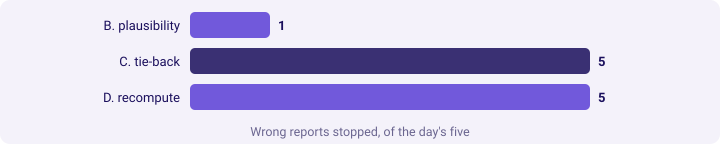

In [3]:
import time


def recompute_in_python(orders_rows, payment_rows):
    """Orders, booked, collected and the gap from the raw rows, with no join: Week 1's accumulator."""
    booked = {o["order_id"]: o["amount"] for o in orders_rows}
    once = {}
    for p in payment_rows:                      # a repeat of one instalment overwrites, so it counts once
        if p["order_id"] in booked:
            once[(p["order_id"], p["instalment_no"])] = p["amount"]
    collected = sum(once.values())
    return {"orders": len(booked), "booked": sum(booked.values()), "collected": collected,
            "gap": sum(booked.values()) - collected}


py_tiny = recompute_in_python(run("SELECT order_id, channel, amount FROM tiny_orders"),
                              run("SELECT order_id, instalment_no, amount FROM tiny_payments"))
wrong_names = [k for k in reports if k != "true report"]
stops = {"B. plausibility": 0, "C. tie-back": 0, "D. recompute": 0}
for name in wrong_names:
    r = reports[name]
    stops["B. plausibility"] += not all(ok for _, ok in validate(r, src_tiny, PLAUSIBLE))
    stops["C. tie-back"] += not all(ok for _, ok in validate(r, src_tiny, TIE_BACK))
    stops["D. recompute"] += any(r[k] != py_tiny[k] for k in ("orders", "booked", "collected", "gap"))
t0 = time.perf_counter(); rep_k = run("""SELECT count(*) AS orders, sum(booked) AS booked, sum(coalesce(collected, 0)) AS collected,
       sum(booked - coalesce(collected, 0)) AS gap, array_agg(DISTINCT channel) AS channels
FROM q2_per_order""")[0]; t_report = time.perf_counter() - t0
t0 = time.perf_counter(); src_k = run("""SELECT (SELECT count(*) FROM orders o WHERE o.quarter = 'Q2')                           AS orders,
       (SELECT sum(amount) FROM orders o WHERE o.quarter = 'Q2')                        AS booked,
       (SELECT sum(amount) FROM payments
         WHERE order_id IN (SELECT order_id FROM orders o WHERE o.quarter = 'Q2'))      AS posted,
       (SELECT sum(amount) FROM orders o WHERE o.quarter = 'Q2' AND
            NOT EXISTS (SELECT 1 FROM payments p
                        WHERE p.order_id = o.order_id))                   AS never_paid,
       (SELECT sum(extra)
          FROM (SELECT sum(p.amount) - max(p.amount) AS extra
                FROM payments p JOIN orders o ON o.order_id = p.order_id WHERE o.quarter = 'Q2'
                GROUP BY p.order_id, p.instalment_no) AS repeats)         AS posted_twice""")[0]; t_src = time.perf_counter() - t0
t0 = time.perf_counter()
py_k = recompute_in_python(run("SELECT order_id, channel, amount FROM orders WHERE quarter = 'Q2'"),
                           run("SELECT order_id, instalment_no, amount FROM payments"))
t_py = time.perf_counter() - t0
kit.table(["Option", "Wrong reports it stops, of 5", "Time on Kalpa's Q2"],
          [("A. read it", "depends on the reader", "minutes of a person"),
           ("B. plausibility", stops["B. plausibility"], f"{t_report * 1000:.0f} ms, the report alone"),
           ("C. tie-back", stops["C. tie-back"], f"{(t_report + t_src) * 1000:.0f} ms, report and sources"),
           ("D. recompute in Python", stops["D. recompute"], f"{t_py * 1000:.0f} ms, the raw rows")],
          caption="Four ways to validate, sized on the day's five wrong reports and on Kalpa's Q2")
kit.bars([(k, v) for k, v in stops.items()], lit=[1], title="Wrong reports stopped, of the day's five")
kit.check("the tie-back suite stops all five wrong reports", stops["C. tie-back"] == 5, f'{stops["C. tie-back"]} of 5')

**The best-fit call.** C, the tie-back suite, with D beside it. The tie-back suite stops all five of
the day's wrong reports and runs in milliseconds, because each check compares a figure on the report
with the same figure computed from one table alone, where no join can multiply or drop anything.
The Python recomputation reaches the numbers by a different tool and a different rule for counting a
payment once, so an error in the SQL and the same error in the checks would still be caught.
Plausibility checks cost the same and stop one report in five.

**The fact that would change the call.** A settlement file from the gateway, the list of what
actually reached Kalpa's bank, would be a source outside Kalpa's own tables, and reconciling to it
would become the strongest check of all; until the platform lead supplies one, every check here
reads Kalpa's own records.

## 1. Do the checks a hurried analyst writes pass a report that hides an unpaid order?

**The plausible wrong answer.** A hurried validation checks what a finance reader expects to be true
of any collections report: collected is at most booked, the gap is not negative, and all three
channels are on the page. It runs on chapter 3's plain JOIN report, which dropped T-4.

**Predict before you run.** How many of the three checks pass? a) none; b) one; c) two; d) all three.

Plausibility check,On the plain JOIN report
collected is at most booked,PASS
the gap is not negative,PASS
all three channels are on it,PASS


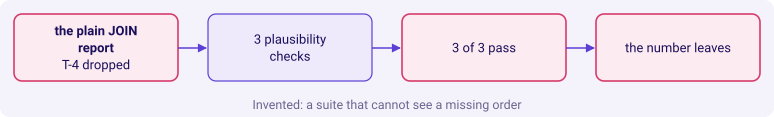

In [4]:
plain = reports["plain JOIN"]
verdicts = validate(plain, src_tiny, PLAUSIBLE)
kit.table(["Plausibility check", "On the plain JOIN report"], [(n_, "PASS" if ok else "FAIL") for n_, ok in verdicts],
          caption=f'Invented: a report of {plain["orders"]} orders, booked {int(plain["booked"]):,}, gap {int(plain["gap"]):,}')
kit.flow(["the plain JOIN report\nT-4 dropped", "3 plausibility checks", "3 of 3 pass", "the number leaves"],
         kinds=["bad", "plain", "bad", "bad"], title="Invented: a suite that cannot see a missing order")
kit.check("the plausibility suite passes the report that hides T-4", all(ok for _, ok in verdicts), "3 of 3")

**What happened.** The answer is d: all three pass. The report shows 4 orders, booked 5,000, collected
5,000 and a gap of 0, and every one of those is internally consistent.

**Why it is wrong.** Each check tests the report against itself. The missing order took its booked
amount with it, so collected is still at most booked, the gap is still not negative, and T-4's
channel, app, is still on the page through T-1. A suite that never looks outside the report cannot
see what the report left out, and it stamps "3 of 3 passed" on a page that hides the one order
nobody paid.

## 2. Which checks tie the report back to the two tables?

Each tie-back check recomputes one figure from a single table and compares it with the report:

| Check | Computed from | Catches |
|---|---|---|
| Orders on the report equal orders in the table | `orders` alone | A dropped or repeated order |
| Booked equals booked from orders alone | `orders` alone | A fan-out, a dropped order |
| The gap equals booked less collected | The report's own columns | A NULL that fell out of a sum |
| The gap equals the unpaid list's total | The anti-join, NOT EXISTS | A dropped order, a wrong list |
| Collected plus posted twice equals posted from payments alone | `payments` alone | A retry inside collected, a fan-out |

**Predict before you run.** On the plain JOIN report, which checks fail? a) none; b) orders, booked
and the unpaid list; c) only the gap; d) all five.

In [5]:
tie = validate(plain, src_tiny, TIE_BACK)
kit.table(["Tie-back check", "On the plain JOIN report"], [(n_, "PASS" if ok else "FAIL") for n_, ok in tie],
          caption="Invented: the same report, checked against the two tables")
kit.check("the tie-back suite fails the plain JOIN report on orders, booked and the unpaid list",
          [ok for _, ok in tie] == [False, False, True, False, True], "3 checks fail")

Tie-back check,On the plain JOIN report
orders on the report equal orders in the table,FAIL
booked equals booked from orders alone,FAIL
the gap equals booked less collected,PASS
the gap equals the unpaid list's total,FAIL
collected plus posted twice equals posted from payments alone,PASS


**What happened.** The answer is b: orders (4 against 5), booked (5,000 against 5,800) and the unpaid
list (a gap of 0 against a list worth 800) all fail, while the report's own arithmetic and its
collected figure pass. The report is internally correct and externally wrong, and only a check that
looks outside it can say so.

## 3. Does the suite fail every wrong report the day has met?

**Predict before you run.** Of the day's five wrong reports, how many does the plausibility suite
let through? a) none; b) one; c) four; d) all five.

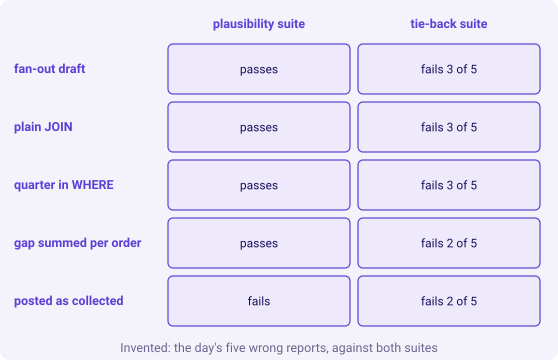

In [6]:
grid, rows = [], []
for name in wrong_names:
    p_ok = all(ok for _, ok in validate(reports[name], src_tiny, PLAUSIBLE))
    t_fail = [n_ for n_, ok in validate(reports[name], src_tiny, TIE_BACK) if not ok]
    grid.append(["passes" if p_ok else "fails", f"fails {len(t_fail)} of 5"])
    rows.append(name)
kit.matrix(rows, ["plausibility suite", "tie-back suite"], grid,
           title="Invented: the day's five wrong reports, against both suites")
through = sum(1 for g in grid if g[0] == "passes")
kit.check("the plausibility suite lets four of the five wrong reports through", through == 4, f"{through} of 5")
kit.check("the tie-back suite fails every wrong report on at least one check",
          all(g[1] != "fails 0 of 5" for g in grid), "5 of 5 stopped")
kit.check("the tie-back suite passes the true report",
          all(ok for _, ok in validate(reports["true report"], src_tiny, TIE_BACK)), "5 of 5 pass")

**What happened.** The answer is c: the plausibility suite lets four through and stops only the report
that read posted as collected, whose collected of 6,500 exceeds booked. The fan-out draft is the
sharpest case: it inflates booked and collected together, so its gap, 800, is even right, and only
the orders and booked checks stop it. The tie-back suite fails every wrong report on at least one
check, and passes the true one on all five.

## 4. Does it pass Kalpa's Q2 report?

The same suite runs on Kalpa's Q2 page from chapter 5. The verdicts print; the figures that would
name what the room is finding stay unprinted.

"Tie-back check, Kalpa's Q2",Verdict,Detail
orders on the report equal orders in the table,PASS,462 against 462
booked equals booked from orders alone,PASS,"Rs 9,84,00,000 against Rs 9,84,00,000"
the gap equals booked less collected,PASS,"equal, unprinted"
the gap equals the unpaid list's total,PASS,"equal, unprinted"
collected plus posted twice equals posted from payments alone,PASS,"equal, unprinted"


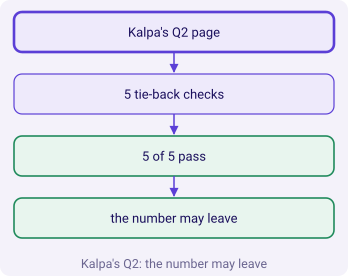

In [7]:
tie_k = validate(rep_k, src_k, TIE_BACK)
detail = {
    "orders on the report equal orders in the table": f'{rep_k["orders"]} against {src_k["orders"]}',
    "booked equals booked from orders alone": f'{kit.rupees(rep_k["booked"])} against {kit.rupees(src_k["booked"])}',
}
kit.table(["Tie-back check, Kalpa's Q2", "Verdict", "Detail"],
          [(n_, "PASS" if ok else "FAIL", detail.get(n_, "equal, unprinted")) for n_, ok in tie_k],
          caption="The suite on Kalpa's Q2 report")
kit.vflow(["Kalpa's Q2 page", "5 tie-back checks", "5 of 5 pass", "the number may leave"],
          kinds=["known", "plain", "good", "good"], title="Kalpa's Q2: the number may leave")
kit.check("every tie-back check passes on Kalpa's Q2 report", all(ok for _, ok in tie_k), "5 of 5")
homes = run("""SELECT coalesce(o.quarter, 'no order') AS home, count(*) AS n FROM payments p
                 LEFT JOIN orders o ON o.order_id = p.order_id GROUP BY 1""")
kit.check("every payment row sits on a Q1 order, a Q2 order or no order, and they add to the table",
          sum(h["n"] for h in homes) == one("SELECT count(*) FROM payments"), "1,428 rows, split unprinted")

**What happened.** Every check passes on Kalpa's Q2 report: 462 orders against 462, booked
Rs 9,84,00,000 against Rs 9,84,00,000, and the gap, the unpaid list and the retries each tie to their
single-table figures. This report may leave the team.

> **Kavya's review.** "A check that cannot fail is decoration. For every check, tell me which wrong
> report it would have stopped, and do not send me a PASS you have never seen fail."

## Does a second tool, working from the raw rows, reach the same numbers?

The second route leaves SQL's joins behind. Two plain SELECTs fetch the raw rows, one table each, and
Python counts them with Week 1's accumulator: booked per order from `orders`, and each order's
instalments from `payments`, keyed by order and instalment so that a repeat of the same instalment
overwrites itself and counts once. It shares no join, no GROUP BY and no NULL rule with the SQL
report, so a mistake in one is unlikely to repeat in the other.

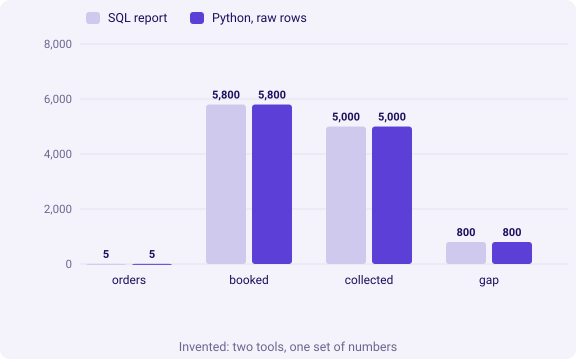

In [8]:
true_tiny = reports["true report"]
kit.columns(["orders", "booked", "collected", "gap"],
            [("SQL report", [float(true_tiny[k]) for k in ("orders", "booked", "collected", "gap")]),
             ("Python, raw rows", [float(py_tiny[k]) for k in ("orders", "booked", "collected", "gap")])],
            fmt=lambda v: f"{v:,.0f}", title="Invented: two tools, one set of numbers")
kit.check("invented: Python from the raw rows matches the SQL report on all four figures",
          all(true_tiny[k] == py_tiny[k] for k in ("orders", "booked", "collected", "gap")), "5 orders, 5,800, 5,000, 800")
kit.check("Kalpa's Q2: Python from the raw rows matches the SQL report on all four figures",
          all(rep_k[k] == py_k[k] for k in ("orders", "booked", "collected", "gap")), "equal, unprinted")

**What happened.** The two tools agree on all four figures, on the invented tables (5 orders, booked
5,800, collected 5,000, gap 800) and on Kalpa's Q2. The Python route has its own blind spot, since
it assumes a retry repeats the same amount, which chapter 3's cap method checked; each route covers
a place the other cannot see.

## 5. What does Anand get when a check fails at the end of reporting day?

A failed check is information, and the day it fails matters: late on reporting day there may be no
time to fix it. The rule the team works to: booked always leaves, because it ties to the orders
table alone; an unreconciled collected figure never leaves; and the open line, which check failed,
what it means and when it will be fixed, goes with it.

| The check that fails | What it means | What Anand gets that day | Who fixes it |
|---|---|---|---|
| Orders on the report against the table | The join dropped or repeated an order | Booked, and "collected held: the join lost or repeated orders" | You |
| Booked against orders alone | A fan-out or a dropped order | Booked from orders alone; collected held | You |
| The gap against booked less collected | A NULL fell out of a sum | The page, with the gap recomputed from the two columns | You |
| The gap against the unpaid list | A list or a bar is wrong | Booked and collected, the gap marked provisional | You, with Kavya |
| Collected plus posted twice against posted | The feed changed, or a retry arrived in a new shape | Booked; collected held; the platform lead told the same day | The platform lead |

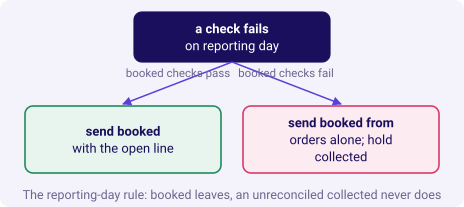

In [9]:
kit.tree({"label": "a check fails\non reporting day", "branches": [
    ("booked checks pass", {"label": "send booked\nwith the open line", "kind": "good"}),
    ("booked checks fail", {"label": "send booked from\norders alone; hold collected", "kind": "bad"}),
]}, taken=["booked checks pass"], title="The reporting-day rule: booked leaves, an unreconciled collected never does")
owners = {"orders on the report equal orders in the table": "you", "booked equals booked from orders alone": "you",
          "the gap equals booked less collected": "you", "the gap equals the unpaid list's total": "you, with Kavya",
          "collected plus posted twice equals posted from payments alone": "the platform lead"}
kit.check("every tie-back check has a named owner for the day it fails", set(owners) == {n_ for n_, _ in TIE_BACK},
          f"{len(owners)} checks, {len(set(owners.values()))} owners")

### [D] Design the validation you run before a joined number reaches Finance, and say what you do when it fails at the end of reporting day.

Four layers, each run every time. First the counts: rows in against rows out, and orders on the
report against orders in the table. Then the tie-backs: booked recomputed from `orders` alone, posted
from `payments` alone, and each bar of the bridge equal to the total of its named list. Then one
independent recomputation, in another tool from the raw rows, or against the gateway's settlement
file when there is one. And a test of the suite itself: run it against the known wrong reports,
the fan-out, the dropped order, the NULL gap, and show that each fails. When a check fails late on
reporting day, send what is reconciled, booked, which ties to orders alone, with the open line
stated, which check failed, what it means and when it will close; hold the collected figure; and
tell the owner the same day. An unreconciled number never leaves with a PASS on it.

### [S] Your join grew the row count: which single check would you keep if you could keep only one?

Orders on the report against orders in the source table. It needs no rupee, it catches a fan-out
and a dropped order alike, and it runs in a millisecond; every other check can be added once that
one passes.

### Depth: why is a settlement file stronger than any check on Kalpa's own tables?

Every check in this suite reads Kalpa's own records, so a record that is wrong at the source, a
payment the feed invented or lost, passes all of them. A settlement file comes from the gateway and
the bank, outside Kalpa, and a difference between it and the payments table is evidence nobody at
Kalpa wrote. That is the lesson the Wirecard audit left.

## What did this chapter answer, one line per question?

1. Three plausibility checks pass the plain JOIN report that hides T-4, 3 of 3, because each tests
   the report against itself.
2. Five tie-back checks compare the report's orders, booked, gap and collected with figures computed
   from one table alone; on the plain JOIN report three of them fail.
3. The plausibility suite lets four of the day's five wrong reports through; the tie-back suite stops
   all five and passes the true report.
4. On Kalpa's Q2 report every tie-back check passes: 462 orders against 462, Rs 9,84,00,000 against
   Rs 9,84,00,000, and the gap and retries tied to their lists.
5. Python, counting the raw rows with no join, reaches the same orders, booked, collected and gap, on
   the invented tables and on Kalpa's Q2.
6. When a check fails at the end of reporting day, Anand gets booked with the open line named, the
   collected figure is held, and the check's owner hears the same day.

**The day's answer, for Anand.** Q2 booked Rs 9,84,00,000; collected, each payment counted once, is
the figure on your own page; the gap is the orders nobody paid, named by channel; the retries and
the payments with no order go to the platform lead; and every figure ties back to the orders and
payments tables through checks that have each been seen to fail.

In [10]:
kit.check_summary()